# 02 — Descriptive Statistics

Exploratory analysis of the event log.

## 1. Imports and Setup

In [ ]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('figs', exist_ok=True)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 100})


## 2. Load & Clean

In [ ]:
dtype_dict = {
    'hired': 'Int8', 'Rejected': 'Int8', 'CW': 'Int8', 'Evergreen': 'Int8',
    'Region': 'Int16', 'Country': 'Int16',
    'Job Family': 'Int16', 'Job Family Group': 'Int16',
}
df = pd.read_csv('data/'+
    'event_log_consolidated.csv',
    low_memory=False,
    dtype=dtype_dict,
    parse_dates=['timestamp']
)

# Filter out numeric-only Step codes
mask_numeric = df['Step'].str.match(r'^\d+$', na=False)
numeric_codes = df.loc[mask_numeric, 'Step'].unique()
print(f'Numeric Step codes filtered out: {sorted(numeric_codes)}')
df = df[~mask_numeric].copy()

df.sort_values(['Case_id', 'timestamp'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape after cleaning: {df.shape}')


Numeric Step codes filtered out: []
Shape after cleaning: (1133314, 17)


In [ ]:
df.head()

,Job_Requisition_Code,Candidate_id,Recruiting Agency,Region,Country,Job Family,Job Family Group,Case_id,CW,Evergreen,Rejected,hired,Completed By,Step,Disposition Reason,All Stages for Candidate Current and Completed,timestamp
0,10fb9be7d6ea,000086ee80c8,NaN,4,15,57,16,000086ee80c8 - 10fb9be7d6ea,0,0,0,0,6746,Review Decision,Candidate Withdrew,Declined by Candidate\n\nInterview\n\nStart,2024-10-17 15:21:25.626
1,10fb9be7d6ea,000086ee80c8,NaN,4,15,57,16,000086ee80c8 - 10fb9be7d6ea,0,0,0,0,7566,Start,Candidate Withdrew,Declined by Candidate\n\nInterview\n\nStart,2024-10-17 15:21:25.626
2,10fb9be7d6ea,000086ee80c8,NaN,4,15,57,16,000086ee80c8 - 10fb9be7d6ea,0,0,0,0,6746,Schedule Interview,Candidate Withdrew,Declined by Candidate\n\nInterview\n\nStart,2024-10-17 15:22:10.434
3,10fb9be7d6ea,000086ee80c8,NaN,4,15,57,16,000086ee80c8 - 10fb9be7d6ea,0,0,0,0,6746,Make Interview Decision,Candidate Withdrew,Declined by Candidate\n\nInterview\n\nStart,2024-10-17 15:22:10.434
4,10fb9be7d6ea,000086ee80c8,NaN,4,15,57,16,000086ee80c8 - 10fb9be7d6ea,0,0,0,0,7566,Recruiter Interview,Candidate Withdrew,Declined by Candidate\n\nInterview\n\nStart,2024-10-17 15:22:10.434


## 3. Core Statistics

In [ ]:
n_events     = len(df)
n_cases      = df['Case_id'].nunique()
n_activities = df['Step'].nunique()
n_resources  = df['Completed By'].nunique()
date_min     = df['timestamp'].min()
date_max     = df['timestamp'].max()

print(f'Events      : {n_events:,}')
print(f'Cases       : {n_cases:,}')
print(f'Activities  : {n_activities}')
print(f'Resources   : {n_resources:,}')
print(f'Date range  : {date_min.date()} -> {date_max.date()}')


Events      : 1,133,314
Cases       : 279,458
Activities  : 58
Resources   : 7,489
Date range  : 2021-01-06 -> 2026-02-12


## 4. Trace Length Distribution

Trace length percentiles:
  p50: 2
  p75: 4
  p90: 7
  p95: 12
  p99: 26

MAX_SEQ_LEN (p95) = 12


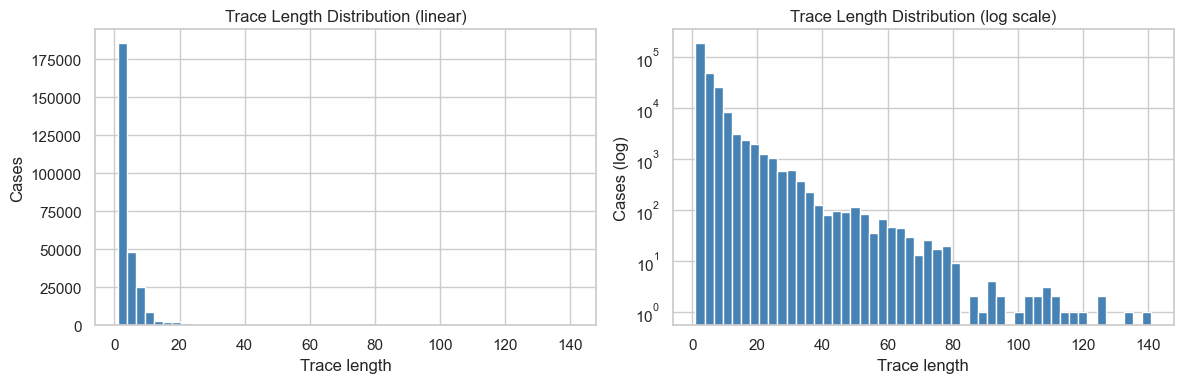

In [ ]:
trace_len = df.groupby('Case_id').size()
pcts = [50, 75, 90, 95, 99]
pct_vals = np.percentile(trace_len, pcts)
print('Trace length percentiles:')
for p, v in zip(pcts, pct_vals):
    print(f'  p{p}: {v:.0f}')
MAX_SEQ_LEN = int(np.percentile(trace_len, 95))
print(f'\nMAX_SEQ_LEN (p95) = {MAX_SEQ_LEN}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(trace_len, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Trace length'); axes[0].set_ylabel('Cases')
axes[0].set_title('Trace Length Distribution (linear)')

axes[1].hist(trace_len, bins=50, color='steelblue', edgecolor='white', log=True)
axes[1].set_xlabel('Trace length'); axes[1].set_ylabel('Cases (log)')
axes[1].set_title('Trace Length Distribution (log scale)')

plt.tight_layout()
plt.savefig('figs/trace_length_distribution.png', bbox_inches='tight')
plt.show()


## 5. Activity Frequency

Top 10 activities by event count:
  Start: 284,587
  Review Decision: 268,611
  Manager Screen: 59,666
  Screen: 51,428
  Schedule Interview: 40,907
  Provide Interview Rating and Comments: 40,506
  Make Interview Decision: 40,395
  Assess Candidate: 27,978
  Make Assessment Decision: 27,977
  Recruiter Interview: 27,888
Top 10 activities by case coverage:
  Start: 279,449
  Review Decision: 268,295
  Screen: 44,854
  Manager Screen: 41,122
  Assess Candidate: 27,393
  Make Assessment Decision: 27,393
  Assessment: 27,017
  Service: Fire Integration: 26,582
  HireVue Assessment: 26,582
  Schedule Interview: 24,330


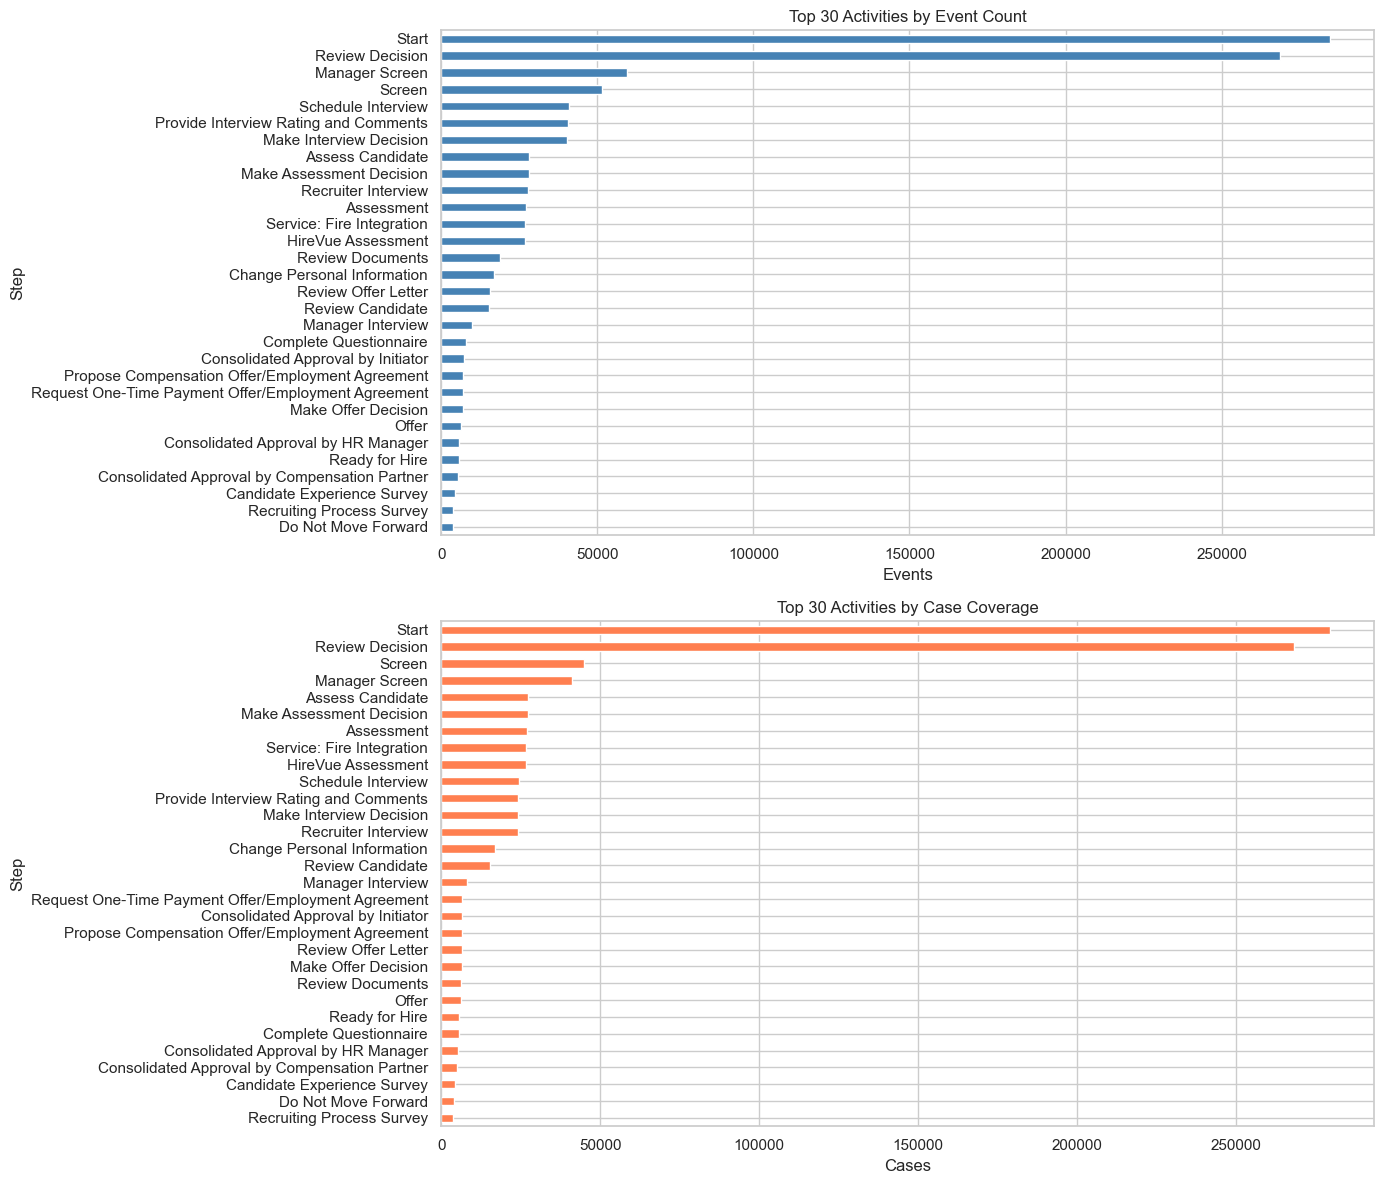

In [ ]:
act_event_cnt = df["Step"].value_counts().head(30)
act_case_cnt  = df.groupby("Step")["Case_id"].nunique().sort_values(ascending=False).head(30)

print("Top 10 activities by event count:")
for act, cnt in act_event_cnt.head(10).items():
    print(f"  {act}: {cnt:,}")

print("Top 10 activities by case coverage:")
for act, cnt in act_case_cnt.head(10).items():
    print(f"  {act}: {cnt:,}")

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
act_event_cnt.sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Top 30 Activities by Event Count")
axes[0].set_xlabel("Events")

act_case_cnt.sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Top 30 Activities by Case Coverage")
axes[1].set_xlabel("Cases")

plt.tight_layout()
plt.savefig("figs/activity_frequency.png", bbox_inches="tight")
try:
    plt.show()
except Exception:
    pass

## 6. Resource Utilization

Total resources: 7,489
Median events/resource: 8
Top 10 resources by event count:
  7566: 445,694
  407: 30,518
  1445: 29,221
  4959: 28,302
  6748: 28,018
  6811: 25,363
  5858: 25,046
  4960: 22,851
  6746: 21,642
  6758: 20,124


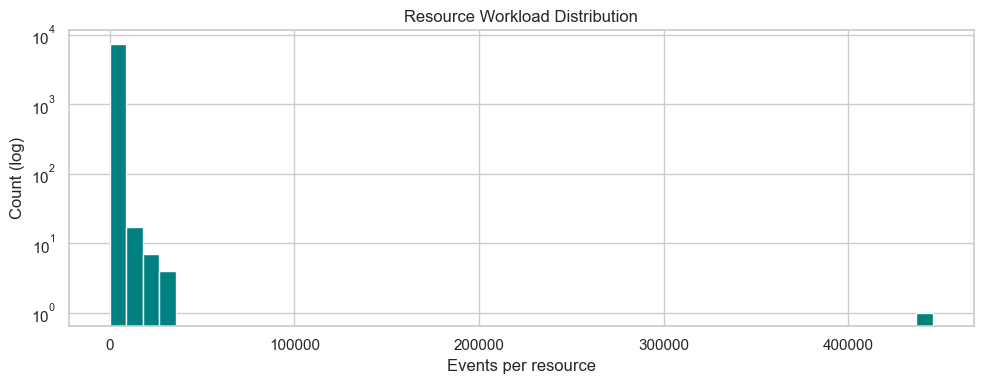

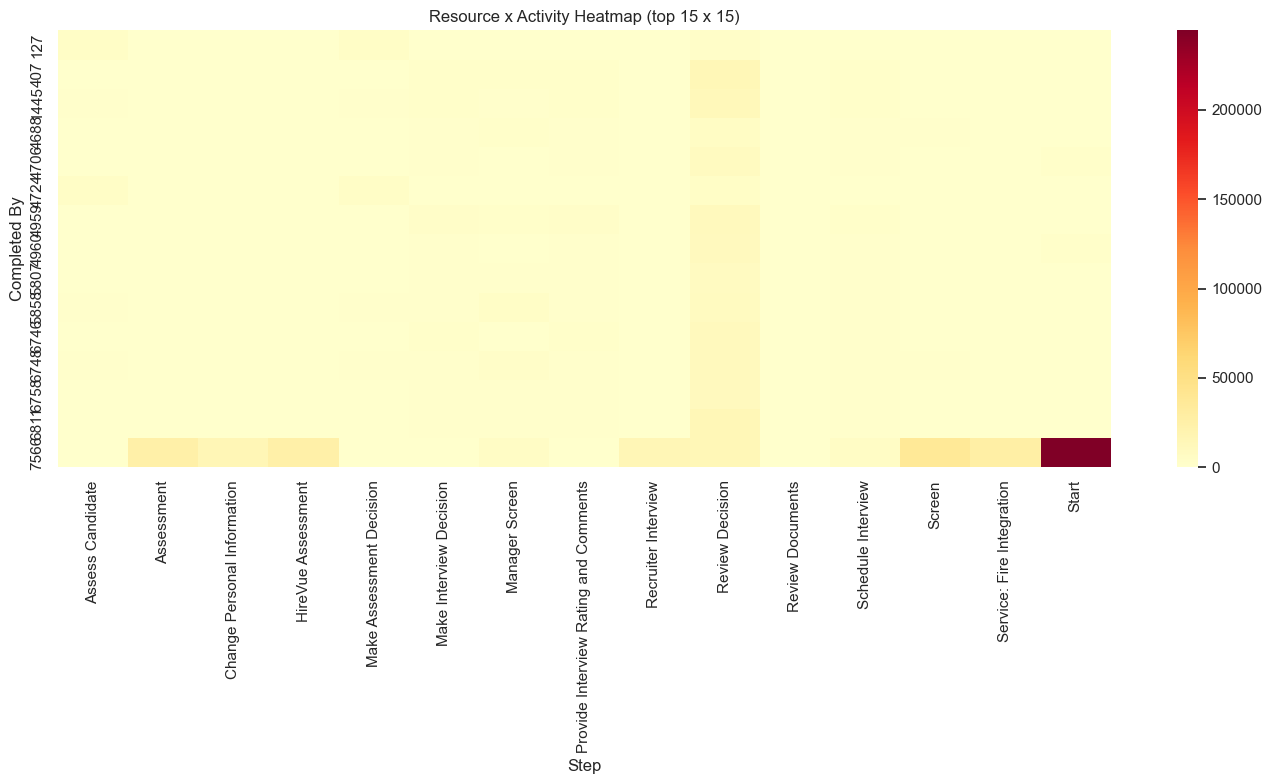

In [ ]:
res_cnt = df["Completed By"].value_counts()

print(f"Total resources: {len(res_cnt):,}")
print(f"Median events/resource: {res_cnt.median():.0f}")
print(f"Top 10 resources by event count:")
for res, cnt in res_cnt.head(10).items():
    print(f"  {res}: {cnt:,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(res_cnt.values, bins=50, color="teal", edgecolor="white", log=True)
ax.set_xlabel("Events per resource"); ax.set_ylabel("Count (log)")
ax.set_title("Resource Workload Distribution")
plt.tight_layout()
plt.savefig("figs/resource_workload.png", bbox_inches="tight")
try:
    plt.show()
except Exception:
    pass

# Heatmap top 15 x 15
top_res = df["Completed By"].value_counts().head(15).index
top_act = df["Step"].value_counts().head(15).index
heat_df = df[df["Completed By"].isin(top_res) & df["Step"].isin(top_act)]
pivot = heat_df.groupby(["Completed By", "Step"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", annot=False)
ax.set_title("Resource x Activity Heatmap (top 15 x 15)")
plt.tight_layout()
plt.savefig("figs/resource_activity_heatmap.png", bbox_inches="tight")
try:
    plt.show()
except Exception:
    pass

## 7. Temporal Patterns

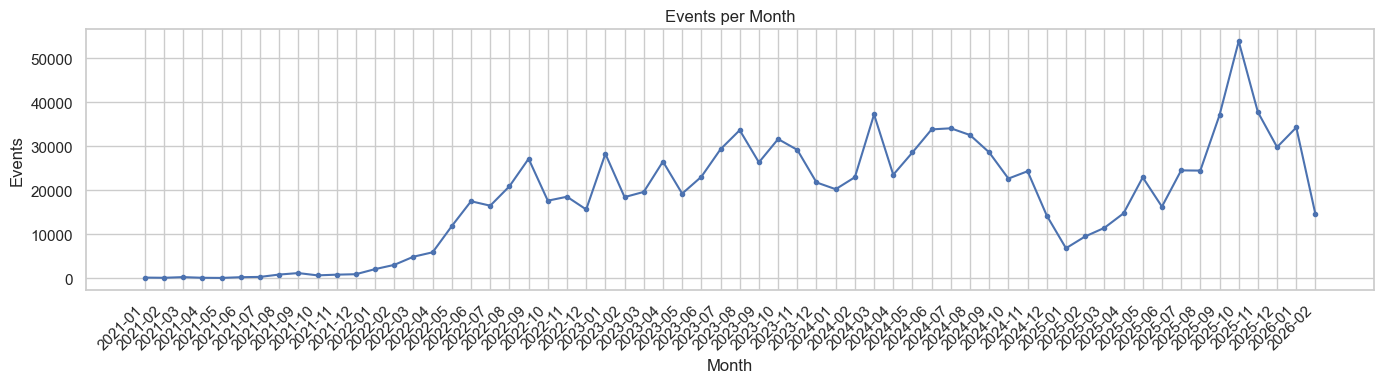

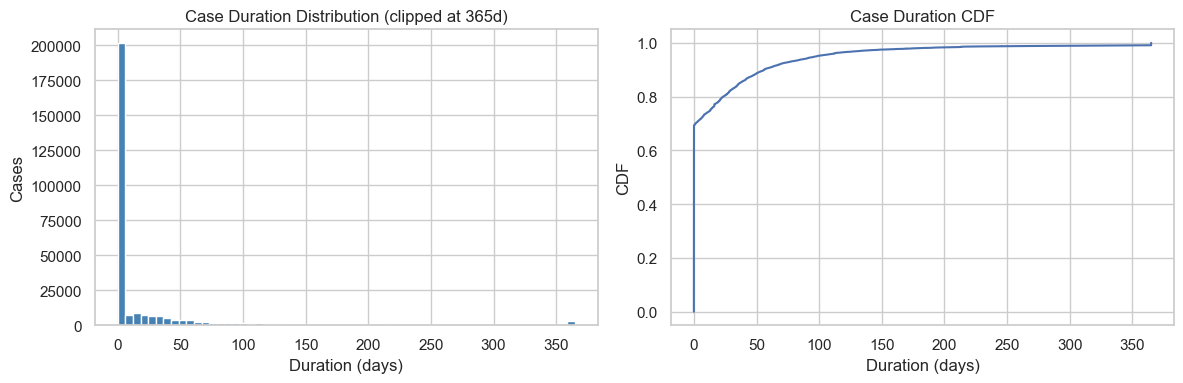

count    279458.000000
mean         18.567284
std          50.771260
min           0.000000
25%           0.000000
50%           0.000000
75%          13.087428
max        1156.289611
Name: duration_days, dtype: float64


In [ ]:
df['year_month'] = df['timestamp'].dt.to_period('M')
monthly = df.groupby('year_month').size()
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly.index, monthly.values, marker='o', markersize=3, linewidth=1.5)
ax.set_xlabel('Month'); ax.set_ylabel('Events')
ax.set_title('Events per Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figs/events_per_month.png', bbox_inches='tight')
plt.show()

case_times = df.groupby('Case_id')['timestamp'].agg(['min', 'max'])
case_times['duration_days'] = (case_times['max'] - case_times['min']).dt.total_seconds() / 86400

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(case_times['duration_days'].clip(upper=365), bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Duration (days)'); axes[0].set_ylabel('Cases')
axes[0].set_title('Case Duration Distribution (clipped at 365d)')

sorted_dur = np.sort(case_times['duration_days'])
cdf = np.arange(1, len(sorted_dur)+1) / len(sorted_dur)
axes[1].plot(sorted_dur.clip(0, 365), cdf)
axes[1].set_xlabel('Duration (days)'); axes[1].set_ylabel('CDF')
axes[1].set_title('Case Duration CDF')

plt.tight_layout()
plt.savefig('figs/case_duration.png', bbox_inches='tight')
plt.show()
print(case_times['duration_days'].describe())


## 8. Outcome Breakdown

Overall hire rate: 2.0%


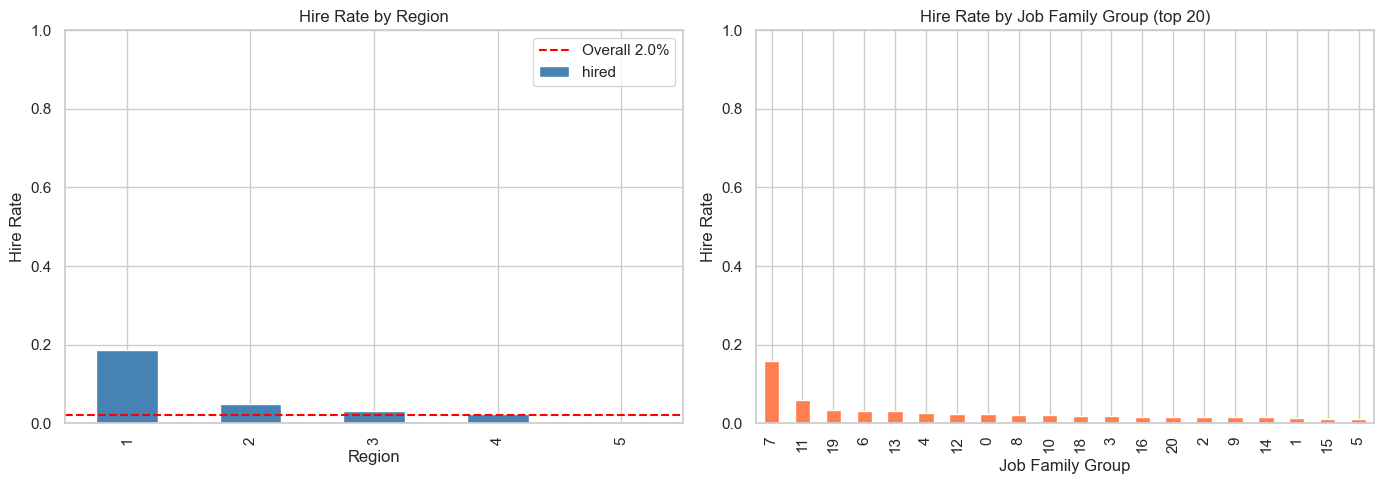

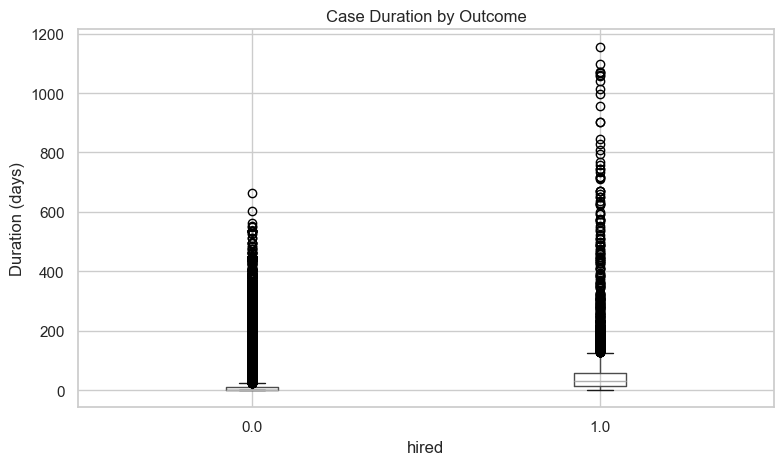

In [ ]:
case_attrs = df.drop_duplicates('Case_id')[['Case_id','hired','Region','Job Family Group']].copy()
case_attrs['hired'] = case_attrs['hired'].astype(float)

overall_hire_rate = case_attrs['hired'].mean()
print(f'Overall hire rate: {overall_hire_rate:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hire_by_region = case_attrs.groupby('Region')['hired'].mean().sort_values(ascending=False)
hire_by_region.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Hire Rate by Region'); axes[0].set_ylabel('Hire Rate')
axes[0].set_ylim(0, 1)
axes[0].axhline(overall_hire_rate, color='red', linestyle='--',
                label=f'Overall {overall_hire_rate:.1%}')
axes[0].legend()

hire_by_jfg = case_attrs.groupby('Job Family Group')['hired'].mean()\
    .sort_values(ascending=False).head(20)
hire_by_jfg.plot.bar(ax=axes[1], color='coral')
axes[1].set_title('Hire Rate by Job Family Group (top 20)')
axes[1].set_ylabel('Hire Rate'); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('figs/outcome_by_group.png', bbox_inches='tight')
plt.show()

case_dur_outcome = case_times.join(case_attrs.set_index('Case_id')[['hired']])
fig, ax = plt.subplots(figsize=(8, 5))
case_dur_outcome.boxplot(column='duration_days', by='hired', ax=ax)
ax.set_title('Case Duration by Outcome')
ax.set_xlabel('hired'); ax.set_ylabel('Duration (days)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('figs/duration_by_outcome.png', bbox_inches='tight')
plt.show()


## 9. Variant Analysis

In [ ]:
variants = df.groupby("Case_id")["Step"].apply(tuple)
variant_counts = variants.value_counts()
n_unique_variants = len(variant_counts)
print(f"Unique variants: {n_unique_variants:,}")

cumsum = variant_counts.cumsum()
total_cases = len(variants)
n_80 = (cumsum <= 0.8 * total_cases).sum()
n_90 = (cumsum <= 0.9 * total_cases).sum()
print(f"Variants covering 80% of cases: {n_80:,}")
print(f"Variants covering 90% of cases: {n_90:,}")

print("Top 10 variants by frequency:")
for variant, cnt in variant_counts.head(10).items():
    label = " -> ".join(variant) if len(variant) <= 5 else " -> ".join(variant[:5]) + f" ... (+{len(variant)-5} more)"
    print(f"  [{cnt:,} cases] {label}")

fig, ax = plt.subplots(figsize=(12, 5))
top30 = variant_counts.head(30)
ax.bar(range(len(top30)), top30.values, color="steelblue")
ax.set_xlabel("Variant rank"); ax.set_ylabel("Cases")
ax.set_title("Top-30 Variant Frequencies")
plt.tight_layout()
plt.savefig("figs/variant_frequency.png", bbox_inches="tight")
try:
    plt.show()
except Exception:
    pass

Unique variants: 17,087
Variants covering 80% of cases: 33
Variants covering 90% of cases: 156
Top 10 variants by frequency:
  [85,208 cases] Start -> Review Decision
  [84,195 cases] Review Decision -> Start
  [6,447 cases] Start
  [4,598 cases] Start -> Start
  [4,473 cases] Review Decision -> Start -> Manager Screen -> Screen
  [4,371 cases] Start -> Review Decision -> Screen -> Manager Screen
  [4,024 cases] Review Decision -> Start -> Screen -> Manager Screen
  [4,013 cases] Start -> Review Decision -> Manager Screen -> Screen


TypeError: sequence item 0: expected str instance, float found

## 10. Key Constants for Downstream Notebooks

In [ ]:
print('=' * 40)
print('KEY CONSTANTS FOR DOWNSTREAM NOTEBOOKS')
print('=' * 40)
print(f'MAX_SEQ_LEN  = {MAX_SEQ_LEN}')
print(f'n_activities = {n_activities}')
print(f'date_range   = {date_min.date()} to {date_max.date()}')
print('SPLIT_DATE   = inspect figs/events_per_month.png to choose')


KEY CONSTANTS FOR DOWNSTREAM NOTEBOOKS
MAX_SEQ_LEN  = 12
n_activities = 67
date_range   = 2021-01-06 to 2026-02-12
SPLIT_DATE   = inspect figs/events_per_month.png to choose


## 11. Concept Drift Analysis — Process Drift Over Time

In [ ]:
# Rolling 3-month windows: hire rate, mean trace length, top-5 activity freq
# Use monthly resolution and smooth with rolling(3)

# Get case-level data with start month
case_level = df.groupby('Case_id').agg(
    start_ts=('timestamp', 'min'),
    n_events=('timestamp', 'count'),
    hired=('hired', 'first')
).reset_index()
case_level['year_month'] = case_level['start_ts'].dt.to_period('M')

monthly_cases = case_level.groupby('year_month').agg(
    n_cases=('Case_id', 'count'),
    hire_rate=('hired', lambda x: x.astype(float).mean()),
    mean_trace_len=('n_events', 'mean')
).reset_index()
monthly_cases['year_month_str'] = monthly_cases['year_month'].astype(str)

# Apply rolling 3-month smoothing
monthly_cases['hire_rate_rolling'] = monthly_cases['hire_rate'].rolling(3, center=True).mean()
monthly_cases['trace_len_rolling'] = monthly_cases['mean_trace_len'].rolling(3, center=True).mean()

# Filter to 2022+ for cleaner analysis (pre-2022 may have sparse data)
monthly_cases_plot = monthly_cases[monthly_cases['year_month'] >= '2022-01'].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Hire rate over time
axes[0].plot(monthly_cases_plot['year_month_str'], 
             monthly_cases_plot['hire_rate'], alpha=0.4, color='steelblue', label='Monthly')
axes[0].plot(monthly_cases_plot['year_month_str'],
             monthly_cases_plot['hire_rate_rolling'], color='steelblue', linewidth=2, label='3M rolling')
axes[0].set_ylabel('Hire Rate')
axes[0].set_title('Hire Rate Over Time (2022–2026)')
axes[0].legend()
n_ticks = len(monthly_cases_plot)
tick_step = max(1, n_ticks // 12)
axes[0].set_xticks(range(0, n_ticks, tick_step))
axes[0].set_xticklabels(monthly_cases_plot['year_month_str'].iloc[::tick_step], 
                         rotation=45, ha='right')

# Mean trace length over time
axes[1].plot(monthly_cases_plot['year_month_str'],
             monthly_cases_plot['mean_trace_len'], alpha=0.4, color='coral', label='Monthly')
axes[1].plot(monthly_cases_plot['year_month_str'],
             monthly_cases_plot['trace_len_rolling'], color='coral', linewidth=2, label='3M rolling')
axes[1].set_ylabel('Mean Trace Length (events)')
axes[1].set_title('Mean Trace Length Over Time (2022–2026)')
axes[1].legend()
axes[1].set_xticks(range(0, n_ticks, tick_step))
axes[1].set_xticklabels(monthly_cases_plot['year_month_str'].iloc[::tick_step],
                         rotation=45, ha='right')

plt.tight_layout()
plt.savefig('figs/drift_hire_rate.png', bbox_inches='tight')
plt.savefig('figs/drift_trace_length.png', bbox_inches='tight')  # same fig, both metrics
try:
    plt.show()
except Exception:
    pass
print('Concept drift plots saved.')

Concept drift plots saved.
